In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv("cleaned_data/IoT_cleaned.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

Rows    : 3876
Columns : 10


In [4]:
df.columns.tolist()

['Latitude',
 'Longitude',
 'Traffic_Speed_kmph',
 'Traffic_Density_vpkm',
 'FFT_Feature_1',
 'FFT_Feature_2',
 'FFT_Feature_3',
 'Vehicle_Count',
 'Time_of_Day_min',
 'Congestion_Level']

In [5]:
df.head()

,Latitude,Longitude,Traffic_Speed_kmph,Traffic_Density_vpkm,FFT_Feature_1,FFT_Feature_2,FFT_Feature_3,Vehicle_Count,Time_of_Day_min,Congestion_Level
0,12.917964,77.623311,55.190066,41.483270,0.185443,0.838712,0.647059,17,852,0
1,13.088692,77.567956,52.085809,31.007323,0.069059,0.176809,0.758469,20,1048,0
2,13.066659,77.660855,37.627867,30.668128,0.264561,0.339073,0.074449,16,73,1
3,13.036142,77.617962,28.233521,29.649618,0.412920,0.286254,0.241308,16,209,1
4,13.082460,77.577661,22.363697,39.744264,0.306188,0.356061,0.769289,29,224,1


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3876 entries, 0 to 3875
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Latitude              3876 non-null   float64
 1   Longitude             3876 non-null   float64
 2   Traffic_Speed_kmph    3876 non-null   float64
 3   Traffic_Density_vpkm  3876 non-null   float64
 4   FFT_Feature_1         3876 non-null   float64
 5   FFT_Feature_2         3876 non-null   float64
 6   FFT_Feature_3         3876 non-null   float64
 7   Vehicle_Count         3876 non-null   int64  
 8   Time_of_Day_min       3876 non-null   int64  
 9   Congestion_Level      3876 non-null   int64  
dtypes: float64(7), int64(3)
memory usage: 302.9 KB


In [7]:
df.isnull().sum()

Latitude                0
Longitude               0
Traffic_Speed_kmph      0
Traffic_Density_vpkm    0
FFT_Feature_1           0
FFT_Feature_2           0
FFT_Feature_3           0
Vehicle_Count           0
Time_of_Day_min         0
Congestion_Level        0
dtype: int64

In [8]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [10]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (3876, 10)


In [11]:
df["Congestion_Level"].value_counts()

Congestion_Level
1    3151
0     644
2      81
Name: count, dtype: int64

In [12]:
df["Congestion_Level"].value_counts().sort_index()

Congestion_Level
0     644
1    3151
2      81
Name: count, dtype: int64

In [13]:
df["Congestion_Level"].value_counts(normalize=True).mul(100).round(2)

Congestion_Level
1    81.30
0    16.62
2     2.09
Name: proportion, dtype: float64

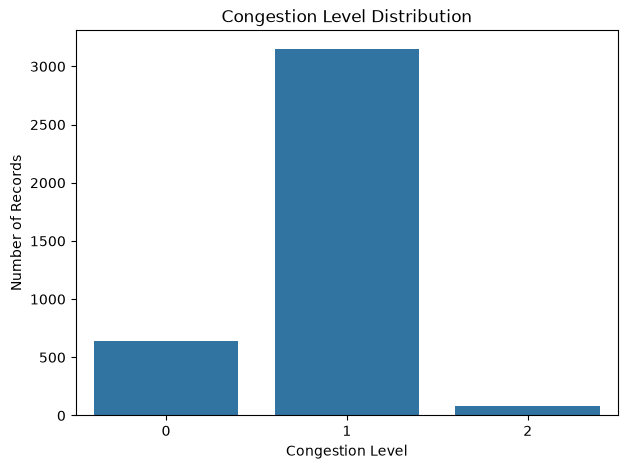

In [14]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Congestion_Level"
)

plt.title("Congestion Level Distribution")
plt.xlabel("Congestion Level")
plt.ylabel("Number of Records")

plt.show()

In [15]:
df.describe()

,Latitude,Longitude,Traffic_Speed_kmph,Traffic_Density_vpkm,FFT_Feature_1,FFT_Feature_2,FFT_Feature_3,Vehicle_Count,Time_of_Day_min,Congestion_Level
count,3876.000000,3876.000000,3876.000000,3876.000000,3876.000000,3876.000000,3876.000000,3876.000000,3876.000000,3876.000000
mean,12.999707,77.599694,40.049252,29.832492,0.501220,0.501889,0.501487,19.898091,730.191176,0.854747
std,0.057699,0.057945,10.057244,7.808380,0.287018,0.285896,0.289958,4.469387,413.142558,0.407422
min,12.900001,77.500036,0.000000,6.120604,0.000105,0.000765,0.000008,7.000000,0.000000,0.000000
25%,12.949019,77.549430,33.074630,24.390824,0.251071,0.259795,0.253836,17.000000,376.500000,1.000000
50%,13.000099,77.600010,39.919187,29.682486,0.505851,0.504521,0.502755,20.000000,724.500000,1.000000
75%,13.048546,77.649657,46.785903,35.142330,0.743428,0.749062,0.755958,23.000000,1092.500000,1.000000
max,13.099958,77.699854,80.155776,64.390861,0.999841,0.999769,0.999940,35.000000,1438.000000,2.000000


In [16]:
categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
[]


In [17]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

Numerical columns:
['Latitude', 'Longitude', 'Traffic_Speed_kmph', 'Traffic_Density_vpkm', 'FFT_Feature_1', 'FFT_Feature_2', 'FFT_Feature_3', 'Vehicle_Count', 'Time_of_Day_min', 'Congestion_Level']


In [18]:
print(df["Congestion_Level"].dtype)
print(df["Congestion_Level"].unique())

int64
[0 1 2]


In [19]:
X = df.drop("Congestion_Level", axis=1)
y = df["Congestion_Level"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3876, 9)
y shape: (3876,)


In [20]:
print(df.columns.tolist())

['Latitude', 'Longitude', 'Traffic_Speed_kmph', 'Traffic_Density_vpkm', 'FFT_Feature_1', 'FFT_Feature_2', 'FFT_Feature_3', 'Vehicle_Count', 'Time_of_Day_min', 'Congestion_Level']


In [21]:
import pandas as pd
import numpy as np

df = pd.read_csv("cleaned_data/IoT_cleaned.csv")

print("Shape:", df.shape)
print(df.columns.tolist())

Shape: (3876, 10)
['Latitude', 'Longitude', 'Traffic_Speed_kmph', 'Traffic_Density_vpkm', 'FFT_Feature_1', 'FFT_Feature_2', 'FFT_Feature_3', 'Vehicle_Count', 'Time_of_Day_min', 'Congestion_Level']


In [22]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3876 entries, 0 to 3875
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Latitude              3876 non-null   float64
 1   Longitude             3876 non-null   float64
 2   Traffic_Speed_kmph    3876 non-null   float64
 3   Traffic_Density_vpkm  3876 non-null   float64
 4   FFT_Feature_1         3876 non-null   float64
 5   FFT_Feature_2         3876 non-null   float64
 6   FFT_Feature_3         3876 non-null   float64
 7   Vehicle_Count         3876 non-null   int64  
 8   Time_of_Day_min       3876 non-null   int64  
 9   Congestion_Level      3876 non-null   int64  
dtypes: float64(7), int64(3)
memory usage: 302.9 KB


In [23]:
df.head()

,Latitude,Longitude,Traffic_Speed_kmph,Traffic_Density_vpkm,FFT_Feature_1,FFT_Feature_2,FFT_Feature_3,Vehicle_Count,Time_of_Day_min,Congestion_Level
0,12.917964,77.623311,55.190066,41.483270,0.185443,0.838712,0.647059,17,852,0
1,13.088692,77.567956,52.085809,31.007323,0.069059,0.176809,0.758469,20,1048,0
2,13.066659,77.660855,37.627867,30.668128,0.264561,0.339073,0.074449,16,73,1
3,13.036142,77.617962,28.233521,29.649618,0.412920,0.286254,0.241308,16,209,1
4,13.082460,77.577661,22.363697,39.744264,0.306188,0.356061,0.769289,29,224,1


In [24]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Latitude                0
Longitude               0
Traffic_Speed_kmph      0
Traffic_Density_vpkm    0
FFT_Feature_1           0
FFT_Feature_2           0
FFT_Feature_3           0
Vehicle_Count           0
Time_of_Day_min         0
Congestion_Level        0
dtype: int64


In [25]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [26]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [27]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (3876, 10)


In [28]:
df["Congestion_Level"].value_counts()

Congestion_Level
1    3151
0     644
2      81
Name: count, dtype: int64

In [29]:
df["Hour"] = (df["Time_of_Day_min"] // 60).astype(int)

print(df[["Time_of_Day_min", "Hour"]].head(10))

   Time_of_Day_min  Hour
0              852    14
1             1048    17
2               73     1
3              209     3
4              224     3
5              418     6
6              408     6
7              130     2
8              946    15
9              177     2


In [30]:
X = df.drop("Congestion_Level", axis=1)

y = df["Congestion_Level"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3876, 10)
y shape: (3876,)


In [31]:
print("Categorical columns:")
print(X.select_dtypes(include=["object", "category"]).columns.tolist())

print("\nNumerical columns:")
print(X.select_dtypes(include=["int64", "float64"]).columns.tolist())

Categorical columns:
[]

Numerical columns:
['Latitude', 'Longitude', 'Traffic_Speed_kmph', 'Traffic_Density_vpkm', 'FFT_Feature_1', 'FFT_Feature_2', 'FFT_Feature_3', 'Vehicle_Count', 'Time_of_Day_min', 'Hour']


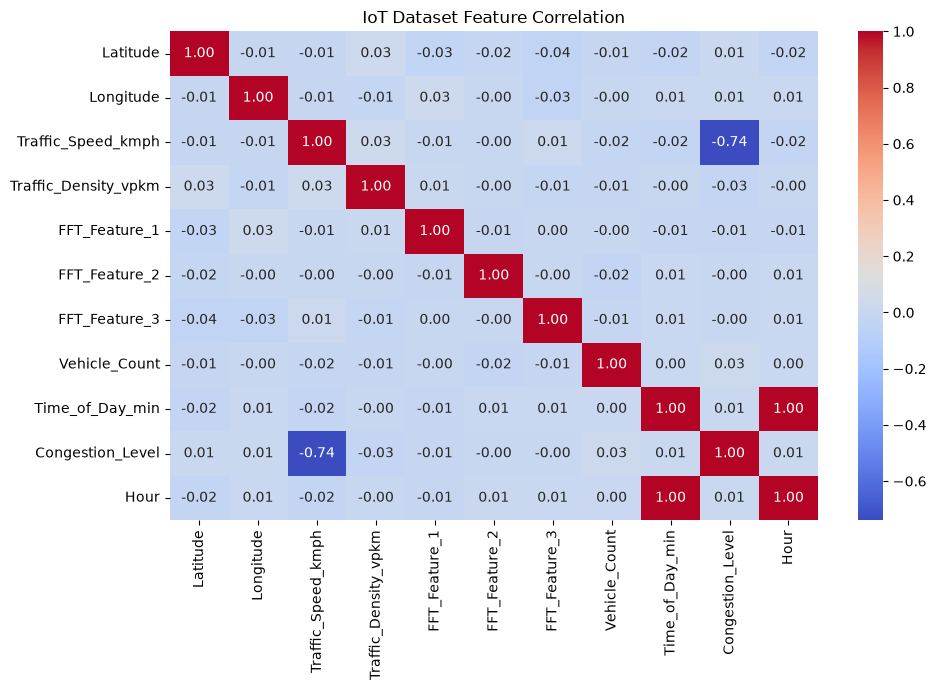

In [32]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("IoT Dataset Feature Correlation")
plt.tight_layout()
plt.show()

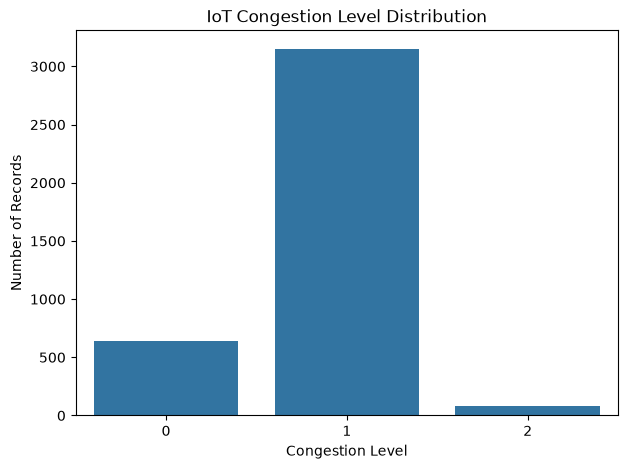

In [33]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Congestion_Level"
)

plt.title("IoT Congestion Level Distribution")
plt.xlabel("Congestion Level")
plt.ylabel("Number of Records")

plt.show()

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 3100
Testing samples : 776


In [35]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest training completed.")

Random Forest training completed.


In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

print("Random Forest")
print("-------------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Random Forest
-------------------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [38]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree training completed.")

Decision Tree training completed.


In [39]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)

dt_precision = precision_score(
    y_test,
    y_pred_dt,
    average="weighted",
    zero_division=0
)

dt_recall = recall_score(
    y_test,
    y_pred_dt,
    average="weighted",
    zero_division=0
)

dt_f1 = f1_score(
    y_test,
    y_pred_dt,
    average="weighted",
    zero_division=0
)

print("Decision Tree")
print("-------------------------")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)

Decision Tree
-------------------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [40]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

lr_model.fit(
    X_train_scaled,
    y_train
)

y_pred_lr = lr_model.predict(X_test_scaled)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [41]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)

lr_precision = precision_score(
    y_test,
    y_pred_lr,
    average="weighted",
    zero_division=0
)

lr_recall = recall_score(
    y_test,
    y_pred_lr,
    average="weighted",
    zero_division=0
)

lr_f1 = f1_score(
    y_test,
    y_pred_lr,
    average="weighted",
    zero_division=0
)

print("Logistic Regression")
print("-------------------------")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

Logistic Regression
-------------------------
Accuracy : 0.9548969072164949
Precision: 0.9638648820186729
Recall   : 0.9548969072164949
F1 Score : 0.956752134021748


In [42]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_model.fit(
    X_train,
    y_train
)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost training completed.")

XGBoost training completed.


In [43]:
xgb_accuracy = accuracy_score(
    y_test,
    y_pred_xgb
)

xgb_precision = precision_score(
    y_test,
    y_pred_xgb,
    average="weighted",
    zero_division=0
)

xgb_recall = recall_score(
    y_test,
    y_pred_xgb,
    average="weighted",
    zero_division=0
)

xgb_f1 = f1_score(
    y_test,
    y_pred_xgb,
    average="weighted",
    zero_division=0
)

print("XGBoost")
print("-------------------------")
print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)

XGBoost
-------------------------
Accuracy : 0.9987113402061856
Precision: 0.9987133792248467
Recall   : 0.9987113402061856
F1 Score : 0.9987093432442357


In [44]:
iot_results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Decision Tree",
        "Logistic Regression",
        "XGBoost"
    ],
    "Accuracy": [
        rf_accuracy,
        dt_accuracy,
        lr_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        rf_precision,
        dt_precision,
        lr_precision,
        xgb_precision
    ],
    "Recall": [
        rf_recall,
        dt_recall,
        lr_recall,
        xgb_recall
    ],
    "F1 Score": [
        rf_f1,
        dt_f1,
        lr_f1,
        xgb_f1
    ]
})

iot_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,1.000000,1.000000,1.000000,1.000000
1,Decision Tree,1.000000,1.000000,1.000000,1.000000
2,Logistic Regression,0.954897,0.963865,0.954897,0.956752
3,XGBoost,0.998711,0.998713,0.998711,0.998709


In [45]:
best_iot_model_name = iot_results.loc[
    iot_results["F1 Score"].idxmax(),
    "Model"
]

print("Best IoT Model:", best_iot_model_name)

Best IoT Model: Random Forest
